In [4]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import logging
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from manifold.decoding.functions.utils import check_config_decoding
import numpy as np
import pickle as pkl
from manifold.decoding.functions import nulldistributions
from communication_subspace.ibl_communication.utils import load_widefield_epoch
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import warnings
from matplotlib import pyplot as plt
warnings.filterwarnings("ignore")
from manifold.utils import get_trial_masks
from glob import glob
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
import statsmodels.stats.multitest as smm
import seaborn as sns
import pickle as pkl
from manifold.widefield_ppi import return_labels

In [5]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
with open("../data/processed/significant_stims_choice.pkl",'rb') as f:
    significant_preloads = pkl.load(f)

In [7]:
from manifold.widefield_decode import prepare_behavior
from manifold.widefield_ppi import aggregate_by_parent, beryl_mapping
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.decomposition import PCA

In [9]:

def cross_temporal_decode_cv_new(
    X_train_epoch, X_test_epoch, Y_train, Y_test, 
    n_components=5, outer_cv_splits=5, inner_cv_splits=3, random_state=42
):
    """
    X_train_epoch: ntrials x N_features (Stimulus Epoch)
    X_test_epoch: ntrials x M_features (Choice Epoch)
    """
    outer_cv = StratifiedKFold(n_splits=outer_cv_splits, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_cv_splits, shuffle=True, random_state=random_state)
    oof_predictions = np.zeros(len(Y_test), dtype=float)
    
    param_grid = {
        "classifier__C": np.logspace(-2, 2, 5),
        "classifier__penalty": ["l2"],
    }
    outer_scores = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_train_epoch, Y_train)):
        

        X_train_fold_A = X_train_epoch[train_idx]
        y_train_fold = Y_train[train_idx]

        X_train_fold_B = X_test_epoch[train_idx] 
        X_test_fold_B = X_test_epoch[test_idx]
        y_test_fold = Y_test[test_idx]

        scaler_A = RobustScaler()
        pca_A = PCA(n_components=n_components, random_state=random_state)
        
        X_train_pca = pca_A.fit_transform(scaler_A.fit_transform(X_train_fold_A))

        scaler_B = RobustScaler()
        pca_B = PCA(n_components=n_components, random_state=random_state)
        
        pca_B.fit(scaler_B.fit_transform(X_train_fold_B))
        X_test_pca = pca_B.transform(scaler_B.transform(X_test_fold_B))

        pipeline = Pipeline([
            ("classifier", LogisticRegression(
                solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=random_state
            ))
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=1,
        )

        grid_search.fit(X_train_pca, y_train_fold)
        best_model = grid_search.best_estimator_


        y_pred_probs = best_model.predict_proba(X_test_pca)[:, 1]
        y_pred = best_model.predict(X_test_pca)

        oof_predictions[test_idx] = y_pred_probs
        fold_score = balanced_accuracy_score(y_test_fold, y_pred)

        outer_scores.append(fold_score)

    return {
        "oof_predictions": oof_predictions,
        "outer_scores": outer_scores,
        "mean_score": np.mean(outer_scores),
        "std_score": np.std(outer_scores),
        "best_model": best_model,
        "grid":grid_search
    }

In [ ]:
def run_crosstemp_congruence_decoding(session_id, n_iterations=10, n_components=5):
    """
    Decodes congruence using subsampled/balanced trials, training on the 
    stimulus epoch and testing on the choice epoch.
    """

    one = ONE(mode="local")
    ssl = SessionLoader(one, session_id)
    ssl.load_trials(collection="alf")
    trials = ssl.trials.copy()

    # Reconstruct behavioral masks
    out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
    trials["signcont"] = out
    trials["stim_side"] = np.sign(trials["signcont"])

    _, stimulus_behavioral_mask = load_trials_and_mask(
        one, session_id, exclude_nochoice=False, exclude_unbiased=False
    )
    stimulus_non_zero_mask = trials["signcont"] != 0
    stim_mask = stimulus_behavioral_mask & stimulus_non_zero_mask
    
    _, choice_behavioral_mask = load_trials_and_mask(
        one, session_id, exclude_nochoice=True, exclude_unbiased=False
    )
    choice_mask = choice_behavioral_mask
    combined_mask = choice_mask & stim_mask

    
    labels, conditions = return_labels(trials, "congruence")
    final_mask = combined_mask & conditions

    
    valid_indices = np.where(final_mask)[0]
    idx_cond_a = [i for i in valid_indices if labels[i] == 1]
    idx_cond_b = [i for i in valid_indices if labels[i] == -1]
    min_trials = min(len(idx_cond_a), len(idx_cond_b))

    # StratifiedKFold in cross_temporal_decode_cv defaults to 5 splits.
    # We need at least 5 trials per class to avoid errors.
    if min_trials < 5: 
        print(f"Skipping {session_id} - not enough trials ({min_trials}/condition).")
        return pd.DataFrame([])

    # Load regions (assuming significant_pickles format from your PPI script)
    stim_regions = ['MOB','MOs','MOp']
    choice_regions = ['PL']
    stim_regions = [[x] for x in stim_regions]
    choice_regions = [[x] for x in choice_regions]

    print("Loading widefield epoch data...")
    config = {'hemisphere':("left", "right")}

    stim_data, stim_region_names = load_widefield_epoch(
        one, session_id, trials, config["hemisphere"], epoch="stim", regions=stim_regions
    )
    choice_data, choice_region_names = load_widefield_epoch(
        one, session_id, trials, config["hemisphere"], epoch="choice", response_time=True, regions=choice_regions
    )

    # parent_mapping = beryl_mapping()
    # stim_data, stim_region_names = aggregate_by_parent(stim_data, stim_region_names, parent_mapping)
    # choice_data, choice_region_names = aggregate_by_parent(choice_data, choice_region_names, parent_mapping)

    session_results = []

    
    for iter_idx in tqdm(range(n_iterations), desc=f"Congruence Decoding Iterations - {session_id}"):
        
    
        sub_a = np.random.choice(idx_cond_a, min_trials, replace=False)
        sub_b = np.random.choice(idx_cond_b, min_trials, replace=False)
        sub_indices = np.concatenate([sub_a, sub_b])
        labels_masked = labels[sub_indices]

        for idx in range(len(stim_data)):
            # Stimulus frame definition (delta: frame 2 - frame 1)
            stim_frame = stim_data[idx][:, sub_indices, :]
            stim_frame = stim_frame[1, :] - stim_frame[0, :]
            stim_region_name = stim_region_names[idx]

            for idy in range(len(choice_data)):
    
                choice_frame = choice_data[idy][:, sub_indices, :]
                choice_frame = choice_frame[1, :]
                choice_region_name = choice_region_names[idy]

                resultx = cross_temporal_decode_cv_new(
                    X_train_epoch=stim_frame, 
                    X_test_epoch=choice_frame, 
                    Y_train=labels_masked, 
                    Y_test=labels_masked, 
                    n_components=n_components,
                    random_state=iter_idx # Seed changes per iteration to vary CV folds
                )

                session_results.append({
                    "session_id": session_id,
                    "iteration": iter_idx,
                    "stim_region": stim_region_name,
                    "choice_region": choice_region_name,
                    "mean_score": resultx["mean_score"],
                    "std_score": resultx["std_score"],
                    "n_trials_per_cond": min_trials,
                    "congruence_score": resultx['grid'].best_score_
                })

    return pd.DataFrame(session_results)

In [11]:
session_id = "f7d46a15-9498-40dc-90da-fb977ce844be"

In [12]:
run_crosstemp_congruence_decoding(session_id, n_iterations=10, n_components=20)

Loading widefield epoch data...


Congruence Decoding Iterations - f7d46a15-9498-40dc-90da-fb977ce844be: 100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


,session_id,iteration,stim_region,choice_region,mean_score,std_score,n_trials_per_cond
0,f7d46a15-9498-40dc-90da-fb977ce844be,0,MOB,PL,0.468972,0.097772,113
1,f7d46a15-9498-40dc-90da-fb977ce844be,0,MO,PL,0.509684,0.059227,113
2,f7d46a15-9498-40dc-90da-fb977ce844be,1,MOB,PL,0.451383,0.095449,113
3,f7d46a15-9498-40dc-90da-fb977ce844be,1,MO,PL,0.455138,0.052361,113
4,f7d46a15-9498-40dc-90da-fb977ce844be,2,MOB,PL,0.455534,0.034897,113
5,f7d46a15-9498-40dc-90da-fb977ce844be,2,MO,PL,0.499605,0.050357,113
6,f7d46a15-9498-40dc-90da-fb977ce844be,3,MOB,PL,0.513636,0.066488,113
7,f7d46a15-9498-40dc-90da-fb977ce844be,3,MO,PL,0.527668,0.069589,113
8,f7d46a15-9498-40dc-90da-fb977ce844be,4,MOB,PL,0.470751,0.109766,113
9,f7d46a15-9498-40dc-90da-fb977ce844be,4,MO,PL,0.466403,0.068060,113


In [13]:
session_id = "f7d46a15-9498-40dc-90da-fb977ce844be"
one = ONE(mode="local")
ssl = SessionLoader(one, session_id)
ssl.load_trials(collection="alf")
trials = ssl.trials.copy()
stim_regions = ["MOB","MOs","MOp"]
choice_regions = ["PL"]

stim_regions =[ [x] for x in stim_regions]
choice_regions = [[x] for x in choice_regions]


config = {'hemisphere':("left", "right")}
stim_data, stim_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="stim", regions=stim_regions)
choice_data, choice_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="choice", response_time=True, regions=choice_regions)

parent_mapping = beryl_mapping()
# stim_data, stim_region_names = aggregate_by_parent(stim_data, stim_region_names, parent_mapping)
# choice_data, choice_region_names = aggregate_by_parent(choice_data, choice_region_names, parent_mapping)

In [27]:
# load stuff and see
session_id

'f7d46a15-9498-40dc-90da-fb977ce844be'

In [22]:
out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
trials["signcont"] = out
trials["stim_side"] = np.sign(trials["signcont"])

_, stim_mask = load_trials_and_mask(one, session_id, exclude_nochoice=False, exclude_unbiased=True)
stimulus_non_zero = trials["signcont"] != 0
stim_mask = stim_mask & stimulus_non_zero

_, choice_mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)

joint_mask = stim_mask & choice_mask


target_stim, _ = prepare_behavior(
    trials, session_id, joint_mask, epoch="stim",pseudosessions=1
)
target_choice, _ = prepare_behavior(
    trials, session_id, joint_mask, epoch="choice",pseudosessions=1,true_choice_pseudo=False
)

2026-07-09 16:21:09,631 [INFO] Preparing behavior targets for epoch: 'stim' with 1 pseudosessions.
2026-07-09 16:21:09,744 [INFO] Preparing behavior targets for epoch: 'choice' with 1 pseudosessions.


In [23]:

results = {}
for region_stim_idx in range(len(stim_data)):
    stim_region = stim_data[region_stim_idx][:, joint_mask, :]
    stim_region = stim_region[1,:]-stim_region[0,:]

    for region_choice_idx in range(len(choice_data)): # should be 1
        choice_region = choice_data[region_choice_idx]
        choice_region = choice_region[1,joint_mask]
        resultx = cross_temporal_decode_cv_new(stim_region, choice_region, target_stim, target_choice,n_components=20)
        key = f'{stim_region_names[region_stim_idx]}, {choice_region_names[region_choice_idx]}'
        results[key] = resultx

In [25]:
results = pd.DataFrame(results)

In [51]:
results

,"['MOB'], ['PL']","['MOs'], ['PL']","['MOp'], ['PL']"
oof_predictions,"[0.5404434857737167, 0.5186264061772435, 0.470...","[0.4520820297417109, 0.5066570089231559, 0.492...","[0.5117017385645598, 0.5017067647682449, 0.513..."
outer_scores,"[0.541019955654102, 0.5025025025025025, 0.5407...","[0.5506810262907824, 0.5345345345345345, 0.575...","[0.502058916693063, 0.5280280280280281, 0.4959..."
mean_score,0.513406,0.533041,0.485684
std_score,0.02449,0.0285,0.031007
best_model,"(LogisticRegression(C=np.float64(100.0), class...","(LogisticRegression(C=np.float64(10.0), class_...","(LogisticRegression(C=np.float64(1.0), class_w..."
grid,"GridSearchCV(cv=StratifiedKFold(n_splits=3, ra...","GridSearchCV(cv=StratifiedKFold(n_splits=3, ra...","GridSearchCV(cv=StratifiedKFold(n_splits=3, ra..."


In [61]:
def plot_true_decoding_performance(results_dict, region_name="Region A -> Region B"):
 
    scores = results_dict['outer_scores']
    mean_score = results_dict['mean_score']
    std_score = results_dict['std_score']
    oof_preds = results_dict['oof_predictions']

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    ax1 = axes[0]
    
 
    sns.stripplot(y=scores, color="darkgray", size=8, jitter=True, ax=ax1, label="Individual Folds")
    
 
    ax1.errorbar(x=0, y=mean_score, yerr=std_score, fmt='o', color="red", 
                 markersize=10, capsize=5, capthick=2, 
                 label=f"Mean ± STD\n({mean_score:.2f} ± {std_score:.2f})")
    
    ax1.axhline(y=0.5, color="black", linestyle="--", linewidth=1.5, label="Chance (0.5)")
    
    ax1.set_xlim(-0.5, 0.5)
    ax1.set_xticks([]) # Remove x-axis ticks
    ax1.set_ylabel("Balanced Accuracy", fontsize=12)
    ax1.set_title(f"CV Fold Performance", fontsize=14)
    ax1.legend(loc='lower right', frameon=False)

    
    ax2 = axes[1]
    
    
    sns.histplot(oof_preds, bins=20, kde=True, color="steelblue", ax=ax2)
    ax2.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Decision Boundary (0.5)")
    
    ax2.set_xlabel("Predicted Probability (Class 1)", fontsize=12)
    ax2.set_ylabel("Number of Trials", fontsize=12)
    ax2.set_title("OOF Prediction Confidence", fontsize=14)
    ax2.legend(frameon=False)

    plt.suptitle(f"Decoding Performance: {region_name}", fontsize=16, y=1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [15]:
with open("../data/processed/significant_stims_choice.pkl",'rb') as f:
    significant_preloads = pkl.load(f)

In [ ]:
stim_targets = {"MOB", "MOp", "MOs"}
choice_targets = {"PL"}
count = 0
for eid in significant_preloads:
    data = significant_preloads[eid]
    stim_exists = stim_targets.issubset(set(data['stim']))
    choice_exists = choice_targets.issubset(set(data['choice']))
    exists = stim_exists & choice_exists

    if exists:
        count = count+1

In [28]:
import pickle as pkl
from glob import glob

In [29]:
files = glob('../data/generated/crosstemporal/*.pkl')

In [ ]:
import glob
import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = glob.glob('../data/generated/crosstemporal/*.pkl')
data = []


for file in files:
    with open(file, 'rb') as f:
        d = pkl.load(f)
        eid = file.rsplit("/")[-1].rsplit("_")[0], 
        for k in d.keys():
            data.append({
                'File': eid,
                'Key': k,
                'Best Score': d[k]['grid'].best_score_,
                'Mean Score': d[k]['mean_score']
            })

df = pd.DataFrame(data)

In [64]:
files = glob.glob('../data/generated/crosstemporal/*.pkl')
data = []

for file in files:
    with open(file, 'rb') as f:
        d = pkl.load(f)
        eid = file.rsplit("/")[-1].rsplit("_")[0], 
        for region in d.keys():
            best_score = d[region]['grid'].best_score_
            mean_score = d[region]['mean_score']
            
            # Only keep regions where the stimulus decoder performed above chance
            if best_score > 0.50:
                data.append({
                    'File': eid, 
                    'Region': region,
                    'Stimulus Epoch (Best)': best_score,
                    'Choice Epoch (Mean)': mean_score,
                    'Unique_ID': f"{eid}_{region}" # Used later to connect pairs
                })

df = pd.DataFrame(data)

In [65]:
df

,File,Region,Stimulus Epoch (Best),Choice Epoch (Mean),Unique_ID
0,"(e95a2528-709a-4590-bf60-cab0715af863,)","['MOB'], ['PL']",0.542798,0.431135,"('e95a2528-709a-4590-bf60-cab0715af863',)_['MO..."
1,"(e95a2528-709a-4590-bf60-cab0715af863,)","['MOs'], ['PL']",0.645329,0.531868,"('e95a2528-709a-4590-bf60-cab0715af863',)_['MO..."
2,"(e95a2528-709a-4590-bf60-cab0715af863,)","['MOp'], ['PL']",0.612025,0.429422,"('e95a2528-709a-4590-bf60-cab0715af863',)_['MO..."
3,"(bf795350-d572-4a06-9ef1-999840edf0f1,)","['MOB'], ['PL']",0.631081,0.641827,"('bf795350-d572-4a06-9ef1-999840edf0f1',)_['MO..."
4,"(bf795350-d572-4a06-9ef1-999840edf0f1,)","['MOs'], ['PL']",0.706675,0.491784,"('bf795350-d572-4a06-9ef1-999840edf0f1',)_['MO..."
...,...,...,...,...,...
86,"(be184bc8-37fb-494c-9fcf-619b10384018,)","['MOs'], ['PL']",0.638092,0.487182,"('be184bc8-37fb-494c-9fcf-619b10384018',)_['MO..."
87,"(be184bc8-37fb-494c-9fcf-619b10384018,)","['MOp'], ['PL']",0.599169,0.563188,"('be184bc8-37fb-494c-9fcf-619b10384018',)_['MO..."
88,"(b83033ed-c5d0-4e49-a595-0a04c48f059d,)","['MOB'], ['PL']",0.627472,0.432517,"('b83033ed-c5d0-4e49-a595-0a04c48f059d',)_['MO..."
89,"(b83033ed-c5d0-4e49-a595-0a04c48f059d,)","['MOs'], ['PL']",0.664590,0.548784,"('b83033ed-c5d0-4e49-a595-0a04c48f059d',)_['MO..."


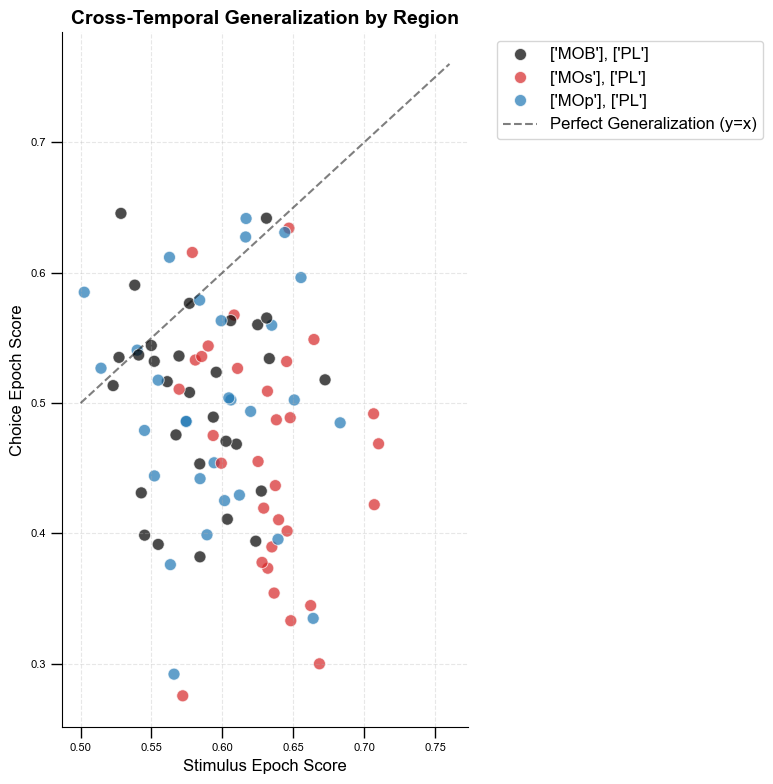

In [67]:
plt.figure(figsize=(8, 8))

# Plot the points, colored by region
sns.scatterplot(
    data=df, 
    x='Stimulus Epoch (Best)', 
    y='Choice Epoch (Mean)', 
    hue='Region', 
    alpha=0.7, 
    s=75
)

min_val = 0.50 # Since we filtered for > 0.50
max_val = max(df['Stimulus Epoch (Best)'].max(), df['Choice Epoch (Mean)'].max()) + 0.05

plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Generalization (y=x)')

plt.title('Cross-Temporal Generalization by Region')
plt.xlabel('Stimulus Epoch Score')
plt.ylabel('Choice Epoch Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

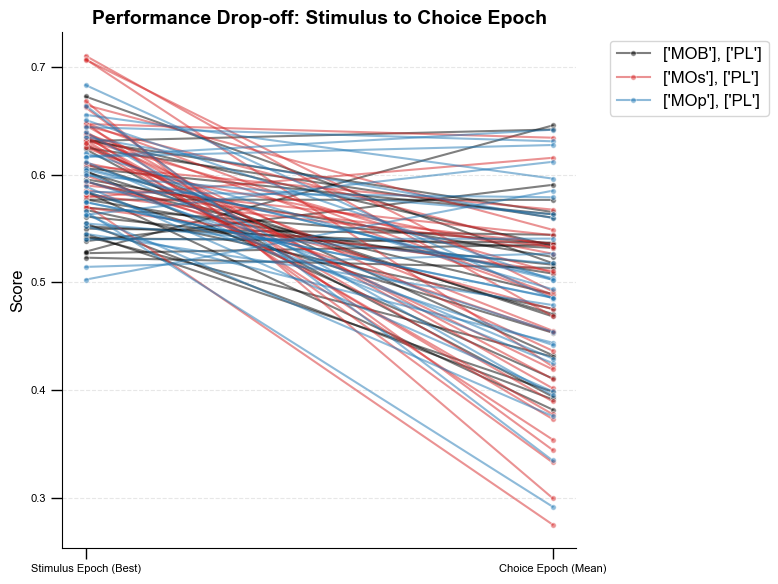

In [68]:
df_melted = df.melt(
    id_vars=['Unique_ID', 'Region'], 
    value_vars=['Stimulus Epoch (Best)', 'Choice Epoch (Mean)'], 
    var_name='Epoch', 
    value_name='Score'
)

plt.figure(figsize=(8, 6))

# Plot lines connecting the pairs. 'units' ensures lines are drawn per specific decoder
sns.lineplot(
    data=df_melted, 
    x='Epoch', 
    y='Score', 
    hue='Region', 
    units='Unique_ID', 
    estimator=None, # Prevents seaborn from aggregating into means
    marker='o', 
    alpha=0.5,
    linewidth=1.5
)

plt.title('Performance Drop-off: Stimulus to Choice Epoch')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
from scipy import stats

In [73]:
files = glob.glob('../data/generated/crosstemporal/*.pkl')
data = []

for file in files:
    with open(file, 'rb') as f:
        d = pkl.load(f)
        for region in d.keys():
            best_score = d[region]['grid'].best_score_
            mean_score = d[region]['mean_score']
            
            if best_score > 0.50:
                data.append({
                    'File': file, 
                    'Region': region,
                    'Stimulus': best_score,
                    'Choice': mean_score,
                    'Unique_ID': f"{file}_{region}"
                })

In [74]:
df = pd.DataFrame(data)

In [75]:
print("--- Statistical Analysis (Paired t-test) ---")
for region in df['Region'].unique():
    region_df = df[df['Region'] == region]
    
    # We need at least 2 data points to run a t-test
    if len(region_df) > 1:
        # ttest_rel calculates the t-test on TWO RELATED samples of scores
        stat, p_val = stats.ttest_rel(region_df['Stimulus'], region_df['Choice'])
        
        # Calculate the average drop for context
        avg_drop = region_df['Stimulus'].mean() - region_df['Choice'].mean()
        
        print(f"Region: {region:<10} | N={len(region_df):<3} | Avg Drop: {avg_drop:.3f} | p-value: {p_val:.4e}")
    else:
        print(f"Region: {region:<10} | Not enough data points to run stats.")

--- Statistical Analysis (Paired t-test) ---
Region: ['MOB'], ['PL'] | N=30  | Avg Drop: 0.078 | p-value: 1.4393e-05
Region: ['MOs'], ['PL'] | N=31  | Avg Drop: 0.173 | p-value: 2.5845e-10
Region: ['MOp'], ['PL'] | N=30  | Avg Drop: 0.098 | p-value: 7.5271e-06


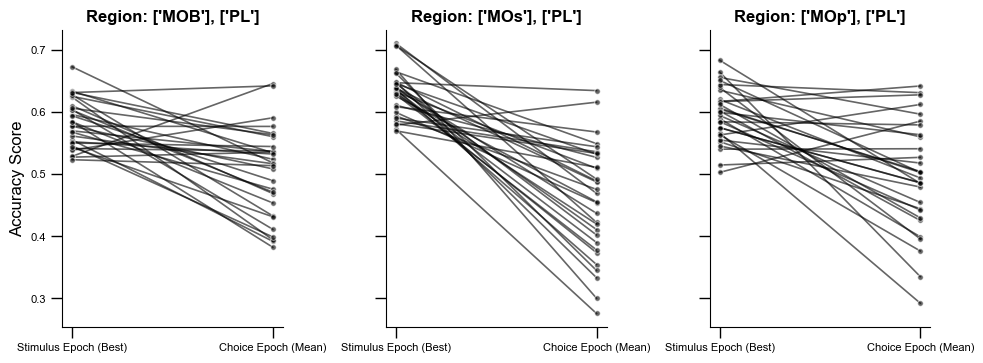

In [76]:
g = sns.relplot(
    data=df_melted, 
    x='Epoch', 
    y='Score', 
    col='Region',     # Create a separate subplot for each Region
    col_wrap=4,       # Adjust this number based on how many regions you have
    units='Unique_ID', 
    estimator=None,   # Draw individual lines, not means
    kind='line', 
    marker='o', 
    alpha=0.6,
    color='black',    # Use a solid color since they are separated by region now
    linewidth=1.2,
    height=4,         # Height of each individual subplot
    aspect=0.8        # Width-to-height ratio of subplots
)

# Clean up the aesthetics
g.set_axis_labels("", "Accuracy Score")
g.set_titles("Region: {col_name}")